# Lesson: GPU vs CPU Benchmark for Image Training

This notebook demonstrates a workload that favors the GPU DirectML setup over CPU.

It uses the Oxford-IIIT Pets dataset and a simple convolutional model to compare runtime.

The dataset is cached locally in `data/` so future runs reuse the same files.

In [23]:
from pathlib import Path
import time

import pandas as pd
import torch
import torch_directml

from fastai.vision.all import *

## Local Dataset Cache

We save the Pets dataset into `data/` so it does not need to be downloaded again on future runs.

In [24]:
local_data_path = Path('data')
local_data_path.mkdir(parents=True, exist_ok=True)

path = Path(untar_data(URLs.PETS, data=local_data_path))

print('Dataset path:', path)
print('Images folder exists:', (path/'images').exists())

Dataset path: C:\Users\Said\.fastai\data\oxford-iiit-pet
Images folder exists: True


## Build the Image DataLoaders

We use the same dataset split for both the GPU and CPU benchmarks.

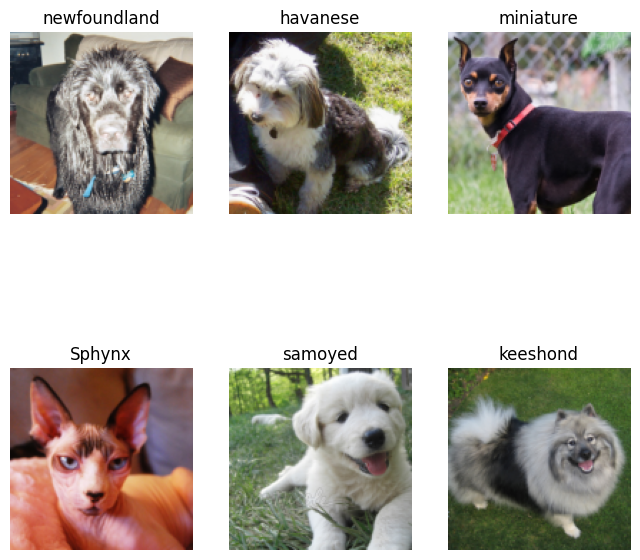

In [25]:
img_path = path/'images'
pat = r'([^/]+)_\d+.jpg$'
# 将lambda函数替换为普通函数以避免Windows上的问题
def label_func(o): 
    # 处理字符串或Path对象
    if hasattr(o, 'name'):
        return o.name.split('_')[0]
    else:
        # 如果o是字符串，则取basename并分割
        import ntpath
        basename = ntpath.basename(o)
        return basename.split('_')[0]

dls_base: DataLoaders = ImageDataLoaders.from_name_func(
    img_path, get_image_files(img_path), label_func,
    valid_pct=0.2, seed=42,
    item_tfms=Resize(128), bs=32,
    num_workers=0
)

dls_base.c = len(dls_base.vocab)
dls_base.show_batch(max_n=6, figsize=(8,8))

## GPU DirectML Benchmark

Train the same ResNet model with the DirectML Adreno device and record the runtime.

In [26]:
gpu_device = torch_directml.device()
print('DirectML device:', torch_directml.device_name(0))

dls_gpu = DataLoaders(
    dls_base.train.new(device=gpu_device),
    dls_base.valid.new(device=gpu_device),
    path=dls_base.path,
    device=gpu_device
)

learn_gpu = cnn_learner(dls_gpu, resnet18, metrics=accuracy).to_fp16(enabled=False)
learn_gpu.to(gpu_device)

def move_norm_tensors_from_learner(learn, device):
    for dl in [learn.dls.train, learn.dls.valid]:
        if hasattr(dl, 'after_batch') and hasattr(dl.after_batch, 'fs'):
            for tfm in dl.after_batch.fs:
                if hasattr(tfm, 'mean') and tfm.mean is not None and tfm.mean.device.type == 'cpu':
                    tfm.mean = tfm.mean.to(device)
                if hasattr(tfm, 'std') and tfm.std is not None and tfm.std.device.type == 'cpu':
                    tfm.std = tfm.std.to(device)

move_norm_tensors_from_learner(learn_gpu, gpu_device)

n_epochs = 2
start = time.perf_counter()
learn_gpu.fit_one_cycle(n_epochs, lr_max=3e-3)
gpu_time = time.perf_counter() - start

print(f'GPU DirectML elapsed: {gpu_time:.2f}s')

DirectML device: Qualcomm(R) Adreno(TM) X1-85 GPU 


epoch,train_loss,valid_loss,accuracy,time
0,5.182248,4.227825,0.035859,02:59
1,5.205964,4.223418,0.033829,02:11


c:\Users\Said\k3sh4v_practicaldeeplearningconsumergpu\.venv\Lib\site-packages\torch\nn\functional.py:1166: UserWarning: The operator 'aten::adaptive_max_pool2d.out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch._C._nn.adaptive_max_pool2d(input, output_size)


GPU DirectML elapsed: 311.14s


## CPU-only Benchmark

Run the same model on CPU to compare the total training time on the same dataset.

In [27]:
cpu_device = torch.device('cpu')
dls_cpu = DataLoaders(
    dls_base.train.new(device=cpu_device),
    dls_base.valid.new(device=cpu_device),
    path=dls_base.path,
    device=cpu_device
)
learn_cpu = cnn_learner(dls_cpu, resnet18, metrics=accuracy).to_fp16(enabled=False)
learn_cpu.to(cpu_device)

start = time.perf_counter()
learn_cpu.fit_one_cycle(n_epochs, lr_max=3e-3)
cpu_time = time.perf_counter() - start

print(f'CPU elapsed: {cpu_time:.2f}s')


AttributeError: add_tfms

In [ ]:
results = pd.DataFrame([
    {
        'setup': 'DirectML Adreno GPU',
        'duration_s': gpu_time,
        'duration_min': gpu_time/60.0,
        'notes': 'GPU path with DirectML'
    },
    {
        'setup': 'CPU-only',
        'duration_s': cpu_time,
        'duration_min': cpu_time/60.0,
        'notes': 'CPU baseline'
    }
])

results

## Benchmark Summary

If the GPU setup is faster, this notebook has demonstrated a workload where the DirectML Adreno path is beneficial.

If the CPU path is still faster, the lesson shows that small or unsupported workloads can remain CPU-bound, and a larger GPU-friendly workload should be chosen.